# Goal: Generate a model of the ***thylakoid system*** of chloroplasts using as reference a cryo-EM structure.

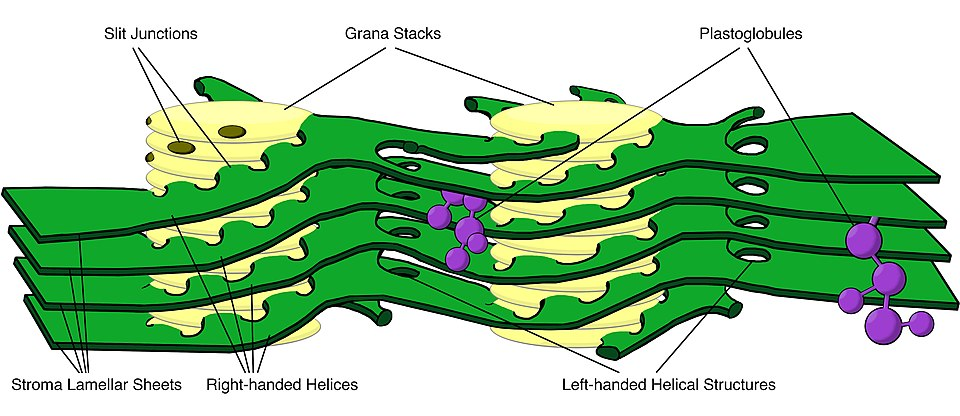

# Thylakoid Membrane Mesh Generation

## Background
The thylakoid system is the main structure inside a chloroplast and is where the photosynthetic proteins are located.

## Objective
`Generate a 3D mesh that can be used to place proteins and lipids on membrane surfaces.`

## Challenges

1. **Incomplete reference data:** Only a partial cryo-EM structure is available, but a geometric description of the system exists.
2. **Periodic model required:** A periodic model enables placement in a periodic simulation box and exploitation of structural symmetry.
3. **Homogeneous face distribution:** Proteins must be distributed uniformly, requiring an even distribution of mesh faces.

## How the Challenges Are Addressed

1. Based on cryo-EM data and associated reported statistics, ad-hoc geometries are generated using experimentally derived parameters.
2. Symmetry operations are used to assemble the system; a representative section is then used as the periodic unit.
3. All geometries can be generated with a user-defined `target_resolution`, producing meshes with uniformly sized faces.

---

**Goal of this notebook:** 
Showcase the thylakoid membrane system and demonstrate the effect of `target_resolution` on mesh quality.



# Import Libraries

In [48]:
import pyvista as pv
import numpy as np
import pyacvd
import os
import math
import matplotlib.pyplot as plt

# Custom modules
from martini_mesh.builders import read_model_parameters, build_granum_mesh, build_right_helix_thylakoid_mesh, build_left_helix_thylakoid_mesh
from martini_mesh.assembly import build_rotational_array, build_linear_array
from martini_mesh.intersections import build_connector_thylakoid_mesh, build_connector_from_loop
from martini_mesh.obj_parsers import load_obj_with_materials, write_mtl_and_update_obj


## Model Parameters

The following parameters define the four structural regions of the thylakoid system:

- **Grana** — stacked membrane disks
- **Right-handed helices** — connect adjacent grana stacks
- **Left-handed helices** — wind around the grana stacks
- **Stroma lamellae** — flat membranes connecting the grana columns

> In the illustration above, the helices and stroma lamellae are merged and shown together in green.

The parameters below are loaded from `model_parameters.yaml`. They can be adjusted,
though the default values best match the experimental cryo-EM data.

| Parameter           | Value  | Description                                                         |
|---------------------|--------|---------------------------------------------------------------------|
| `radius_granum`     | 125 nm | Radius of the granum cylinder                                       |
| `height_crosssection` | 18 nm | Height of each granum disk; also sets the helix tube cross-section |
| `membrane_thickness` | 4 nm  | Thylakoid membrane thickness (useful for by TS2CG)                  |
| `stromal_gap`       | 3 nm   | Gap between stacked grana                                           |
| `n_granum`          | 10     | Number of disks in the granum stack                                 |
| `inner_pore`        | 25 nm  | Inner radius of the left-handed helix cross-section                 |
| `tilt_angle`        | 18.45° | Tilt angle of both helix types, not recommended to change

In [49]:
# Load model parameters from YAML file
dict_params = read_model_parameters("martini_mesh/model_parameters.yaml")


# 🎨 Pallete 

In [27]:
pallete = {
    "green":       (0.525, 0.796, 0.220),  # 86CB38
    "lightgreen": (0.804, 0.969, 0.435),  # CDF76F
    "yellow":      (0.918, 0.769, 0.200),  # EAC433
    "orange":      (0.902, 0.439, 0.149),  # E67026
    "red":         (0.871, 0.216, 0.075),  # DE3713
    "violet":      (0.498, 0.000, 1.000),  # D04DF1
    "pink":        (0.906, 0.537, 0.984),  # E789FB
    "blue":        (0.184, 0.302, 0.812),  # 2F4DCF
    "purple":      (0.400, 0.247, 0.933),  # 663FEE
    "lightblue":   (0.627, 0.839, 0.839),  # A0D6D6
    "grey":         (0.600, 0.600, 0.600),  # 999999
    "black":        (0.000, 0.000, 0.000),  # 000000
    "white":        (1.000, 1.000, 1.000),  # FFFFFF
}

# Grana region 

The followig code generates a granum with a radius of `radius_granum` and a thickness of `height_crosssection`



In [28]:
granum_mesh = build_granum_mesh(target_resolution=0.5)

Area of a single granum: 112312 nm^2
Target faces for 0.5 nm^2/face: 224623
Granum separation (with stromal gap): 25 nm
The mesh has 224618 faces.
The average cell size is 0.50 nm^2.
The standard deviation of the cell sizes is 0.07 nm^2.


>Zoom in to visualize the faces, each one has the desired `target_resolution`

In [29]:
#--- Plot the cylinders
granum_plot = pv.Plotter(window_size=[1800, 600])
granum_plot.background_color = 'grey'
# Add the cryo-mesh for context
granum_plot.add_mesh(granum_mesh, color="yellow", show_edges=True, opacity=1.0)
# Show the plot
granum_plot.show()

Widget(value='<iframe src="http://localhost:61950/index.html?ui=P_0x16aa5d2a0_9&reconnect=auto" class="pyvista…

# Right-handed helix

>Zoom in to visualize the faces, each one has the desired `target_resolution`

In [30]:
# Right-handed helix
right_helix_mesh = build_right_helix_thylakoid_mesh(dict_params, target_resolution=0.5, verbose=True)

Radius of right helix spline: 143.00 nm
Width of right helix: 37.00 nm
The mesh has 201124 faces.
The average cell size is 0.51 nm^2.
The standard deviation of the cell sizes is 0.04 nm^2.


In [31]:
#--- Plot the right-handed helix
plot_right_helix = pv.Plotter(window_size=[1800, 600])
plot_right_helix.background_color = 'grey'
plot_right_helix.add_mesh(right_helix_mesh, color="lightblue", show_edges=True, opacity=1.0)
plot_right_helix.show()

Widget(value='<iframe src="http://localhost:61950/index.html?ui=P_0x12ab0b430_10&reconnect=auto" class="pyvist…

# Left-handed helix


In [32]:
left_helix_mesh = build_left_helix_thylakoid_mesh(dict_params, target_resolution=0.5, verbose=True)

Radius of left helix spline: 35.75 nm
Width of left helix: 21.50 nm
d_granum_helix: 192.80 nm
The mesh has 143660 faces.
The average cell size is 0.51 nm^2.
The standard deviation of the cell sizes is 0.11 nm^2.


>Zoom in to visualize the faces, each one has the desired `target_resolution`

In [33]:
#--- Plot left-handed helix
plot_left_helix = pv.Plotter(window_size=[1800, 600])
plot_left_helix.background_color = 'grey'
plot_left_helix.add_mesh(left_helix_mesh, color="purple", show_edges=True, opacity=1.0)

plot_left_helix.add_mesh(right_helix_mesh, color="lightblue", show_edges=True, opacity=1.0) #Add the right-handed helix for comparison
#plot_left_helix.add_mesh(right_helix_mesh, color="lightblue", show_edges=False, opacity=1.0)
plot_left_helix.show()

Widget(value='<iframe src="http://localhost:61950/index.html?ui=P_0x16aa96800_11&reconnect=auto" class="pyvist…

# Assemblies: Generating the model based on the simple shapes that we generated

## Grana stacks

We will generate `ten` extra copies of the `granum`, evenly spaced along the z-axis

In [34]:
grana_stacks_array = build_linear_array(granum_mesh)

In [35]:
#--- Plot the grana stacks array
plot_grana_stacks = pv.Plotter(window_size=[1800, 600])
plot_grana_stacks.background_color = 'black'
# Add the cryo-mesh for context
plot_grana_stacks.add_mesh(grana_stacks_array, color="yellow", show_edges=False, opacity=1.0)
# Show the plot
plot_grana_stacks.show()

Widget(value='<iframe src="http://localhost:61950/index.html?ui=P_0x16aa972e0_12&reconnect=auto" class="pyvist…

## Right-handed helices

We will generate `three` extra copies of the `right_handed helices`, evenly rotated along the z-axis

In [36]:
right_handed_helices = build_rotational_array(right_helix_mesh, n_copies=4)


In [37]:
#--- Plot the right-handed helices
plot_right_helices = pv.Plotter(window_size=[1800, 600])
plot_right_helices.background_color = 'black'
# Add the cryo-mesh for context
plot_right_helices.add_mesh(right_handed_helices, color="lightblue", show_edges=False, opacity=1.0)
# Show the plot
plot_right_helices.show()

Widget(value='<iframe src="http://localhost:61950/index.html?ui=P_0x16aa5c640_13&reconnect=auto" class="pyvist…

We will generate `three` extra copies of the `left_handed_helix`, evenly rotated along the z-axis.

The assembly will look differently to the `right_handed_helix` as it is center at the origin while the other at a distance from the the z-axis definied by `radius_granum` + `height_crosssection` + `inner_pore`




In [38]:
left_handed_helices = build_rotational_array(left_helix_mesh, n_copies=4)

In [39]:
#--- Plot left-handed helices, the stacks and the right-handed helices
plot_left_handed_helices = pv.Plotter(window_size=[1800, 600])
plot_left_handed_helices.background_color = 'black'
plot_left_handed_helices.add_mesh(left_handed_helices, color="purple", show_edges=False, opacity=1.0)
#plot_left_handed_helices.add_mesh(grana_stacks_array, color="yellow", show_edges=False, opacity=1.0)
plot_left_handed_helices.add_mesh(right_handed_helices, color="lightblue", show_edges=False, opacity=1.0)
# Show the plot
plot_left_handed_helices.show()

Widget(value='<iframe src="http://localhost:61950/index.html?ui=P_0x16aa5c820_14&reconnect=auto" class="pyvist…

## Stromma lamellae

This section is form by the intersections between the two types of helices and at longer distances it becomes planar. 

The implementation is the most complex so far, but in simple terms, it generates a loop with these characteristics that then can be transformed into a mesh.

In [40]:
connector_mesh = build_connector_thylakoid_mesh(dict_params, target_resolution=0.5) 
#Here the std is high because only part of of the mesh is been subject to target_resolution.


The mesh has 56670 faces.
The average cell size is 0.69 nm^2.
The standard deviation of the cell sizes is 2.63 nm^2.


In [41]:
#--- Plot the connector loop
plot_connector = pv.Plotter(window_size=[1800, 600])
plot_connector.background_color = 'grey'
plot_connector.add_mesh(connector_mesh, color="green", show_edges=False, opacity=1.0)
plot_connector.add_mesh(right_handed_helices, color="lightblue", show_edges=False, opacity=1.0)
plot_connector.add_mesh(left_handed_helices, color="purple", show_edges=False, opacity=1.0)
plot_connector.show() 

Widget(value='<iframe src="http://localhost:61950/index.html?ui=P_0x16bb7ead0_15&reconnect=auto" class="pyvist…

Each `stroma_lamellae` plane is composed of `eight` of these meshes, alternating orientation

In [42]:
from martini_mesh.assembly import build_connector_thylakoid_array

all_connectors = build_connector_thylakoid_array(dict_params, connector_mesh)


z0: 38.74 nm  |  4 levels at: [ 38.7 113.7 188.6 263.6]


# Final model: All the pieces together

In [43]:
#--- Plot the connector loop
plot_connector_all = pv.Plotter(window_size=[1800, 600])
plot_connector_all.background_color = 'black'
plot_connector_all.add_mesh(grana_stacks_array, color="yellow", show_edges=False, opacity=1.0)
plot_connector_all.add_mesh(right_handed_helices, color="lightblue", show_edges=False, opacity=0.5)
plot_connector_all.add_mesh(left_handed_helices, color="purple", show_edges=False, opacity=1.0)
plot_connector_all.add_mesh(all_connectors, color="green", show_edges=False, opacity=1)
plot_connector_all.show() 

Widget(value='<iframe src="http://localhost:61950/index.html?ui=P_0x12ab0a6e0_16&reconnect=auto" class="pyvist…

### References:
`Cryo-EM data`: Bussi, Y., Shimoni, E., Weiner, A., Kapon, R., Charuvi, D., Nevo, R., ... & Reich, Z. (2019). Fundamental helical geometry consolidates the plant photosynthetic membrane. Proceedings of the National Academy of Sciences, 116(44), 22366-22375.